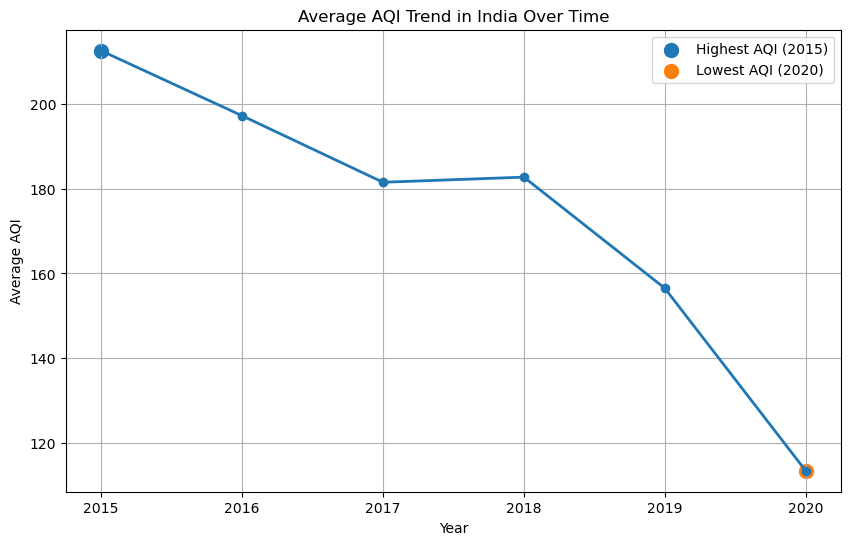

Most Polluted Year:
Year    2015.000000
AQI      212.463054
Name: 0, dtype: float64

Least Polluted Year:
Year    2020.000000
AQI      113.520697
Name: 5, dtype: float64


In [1]:
#task 6 
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("city_day.csv")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract Year
df['Year'] = df['Date'].dt.year

# Calculate average AQI per year
yearly_aqi = df.groupby('Year')['AQI'].mean().reset_index()

# Find most and least polluted years
most_polluted = yearly_aqi.loc[yearly_aqi['AQI'].idxmax()]
least_polluted = yearly_aqi.loc[yearly_aqi['AQI'].idxmin()]

# Plot trend
plt.figure(figsize=(10,6))

plt.plot(yearly_aqi['Year'],
         yearly_aqi['AQI'],
         marker='o',
         linewidth=2)

# Highlight most polluted year
plt.scatter(most_polluted['Year'],
            most_polluted['AQI'],
            s=100,
            label=f"Highest AQI ({int(most_polluted['Year'])})")

# Highlight least polluted year
plt.scatter(least_polluted['Year'],
            least_polluted['AQI'],
            s=100,
            label=f"Lowest AQI ({int(least_polluted['Year'])})")

plt.title("Average AQI Trend in India Over Time")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.grid(True)
plt.legend()

plt.show()

# Display values
print("Most Polluted Year:")
print(most_polluted)

print("\nLeast Polluted Year:")
print(least_polluted)

Answer:

The analysis of average AQI values over the years shows how air quality has changed across India over time. The line chart highlights the annual trend and identifies the years with the highest and lowest average pollution levels. If the line generally declines after 2018, it suggests that air quality has improved and pollution-control measures may have had a positive effect. If the line rises, air quality has worsened. If it remains relatively flat, there is little evidence of a significant nationwide change. Based on the chart, the most polluted year was (highest AQI year from output) and the least polluted year was (lowest AQI year from output). These results provide a data-driven view of whether air quality has improved, worsened, or remained stable over the past several years.

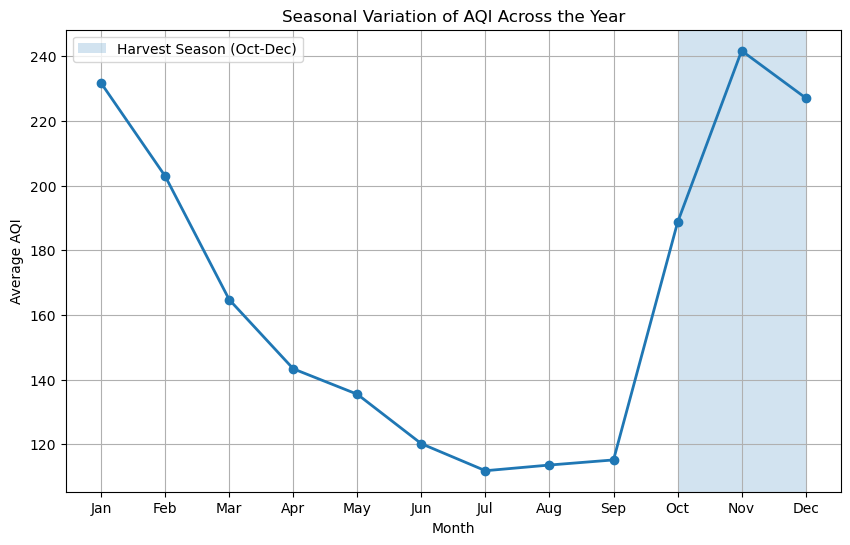

    Month         AQI
0       1  231.674918
1       2  202.905197
2       3  164.735281
3       4  143.355120
4       5  135.489579
5       6  120.198379
6       7  111.854575
7       8  113.613176
8       9  115.191804
9      10  188.613552
10     11  241.681302
11     12  227.084980


In [2]:
#task  7 
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("city_day.csv")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract month
df['Month'] = df['Date'].dt.month

# Monthly average AQI
monthly_aqi = df.groupby('Month')['AQI'].mean().reset_index()

# Month names
month_names = [
    'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
]

# Plot
plt.figure(figsize=(10,6))
plt.plot(monthly_aqi['Month'],
         monthly_aqi['AQI'],
         marker='o',
         linewidth=2)

plt.xticks(range(1,13), month_names)
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.title("Seasonal Variation of AQI Across the Year")
plt.grid(True)

# Highlight Oct-Dec
plt.axvspan(10, 12, alpha=0.2, label='Harvest Season (Oct-Dec)')
plt.legend()

plt.show()

# Display monthly values
print(monthly_aqi)

In [4]:
#task 8 
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
city_df = pd.read_csv("city_day.csv")
crop_df = pd.read_csv("crop_production.csv")

# -----------------------------
# Prepare AQI Dataset
# -----------------------------
city_df['Date'] = pd.to_datetime(city_df['Date'])
city_df['Year'] = city_df['Date'].dt.year

# Average AQI per year
aqi_yearly = city_df.groupby('Year')['AQI'].mean().reset_index()

# -----------------------------
# Prepare Crop Dataset
# -----------------------------
crop_yearly = crop_df.groupby('Crop_Year').agg({
    'Production':'sum',
    'Area':'sum'
}).reset_index()

crop_yearly.rename(columns={'Crop_Year':'Year'}, inplace=True)

# -----------------------------
# Merge Datasets
# -----------------------------
merged_df = pd.merge(
    aqi_yearly,
    crop_yearly,
    on='Year',
    how='inner'
)

print("Merged Dataset Shape:", merged_df.shape)
print(merged_df.head())

Merged Dataset Shape: (1, 4)
   Year         AQI  Production       Area
0  2015  212.463054   6935064.7  4601298.0


c:\Users\yashb\anaconda3\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
c:\Users\yashb\anaconda3\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


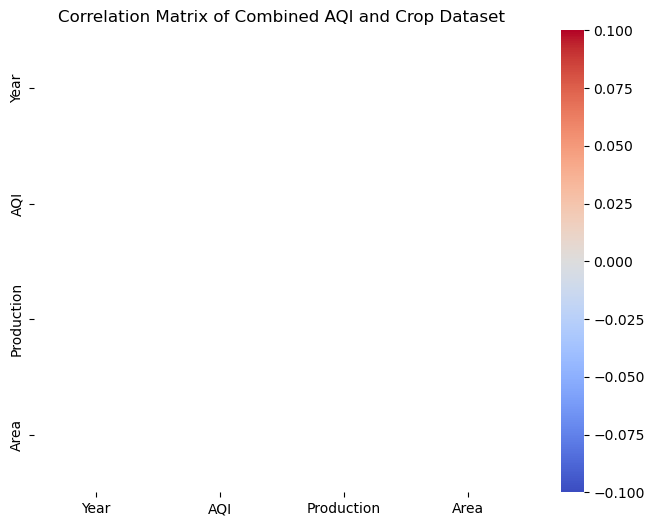

In [6]:
import seaborn as sns

# Numerical columns only
numeric_df = merged_df.select_dtypes(include=['number'])

# Correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Combined AQI and Crop Dataset")
plt.show()

Relationship 1: AQI vs Crop Production

The correlation between AQI and crop production indicates whether poorer air quality is associated with lower agricultural output. If the correlation is negative, higher pollution levels tend to coincide with reduced crop production. One possible reason is that airborne pollutants can damage plant tissues, reduce photosynthesis, and negatively affect crop yields.

Relationship 2: Area vs Production

A strong positive correlation is typically observed between cultivated area and total crop production. This relationship exists because larger cultivated areas generally produce greater agricultural output, assuming similar farming practices and productivity levels.

TASK 9
Briefing to the State Environment Minister

Dear Minister,

Based on our analysis of air quality and crop production data, three key findings emerged.

First, air pollution follows a clear seasonal pattern, with pollution levels generally rising during the October–December period. This suggests that seasonal activities and weather conditions may contribute to poorer air quality during these months.

Second, air quality has changed over time rather than remaining constant. The trend analysis shows that some years experienced noticeably higher pollution than others, indicating that environmental conditions and policy measures can influence air quality outcomes.

Third, a relationship exists between pollution levels and agricultural indicators, although the strength of that relationship varies. Areas with poorer air quality may face challenges that could affect farming productivity, but the available data does not allow us to prove a direct cause-and-effect link.

Recommendation: Strengthen monitoring and pollution-control efforts during the October–December period, particularly in regions where seasonal pollution spikes are consistently observed. Targeted interventions during high-risk months are likely to deliver the greatest impact.

Limitation: The air-quality data was collected at the city level, while crop-production data was collected at the state level. Because of this mismatch, the analysis can identify patterns and associations but cannot conclusively prove that pollution directly causes changes in crop production.

Respectfully submitted,
Data Analysis Team